In [1]:
#1
import tensorflow as tf

print('Eager Execution :' , tf.executing_eagerly())
a = tf.constant([[2,3],[5,6]])
b = tf.constant([[1,2],[3,4]])
matmultification = tf.matmul(a,b)
add=tf.add(a,b)
mul=tf.multiply(a,b)

print(matmultification)
print(add)
print(mul)

x=tf.Variable(5.0)
for i in range (3):
  x.assign_add(2.0)
  print(x.numpy())

Eager Execution : True
tf.Tensor(
[[11 16]
 [23 34]], shape=(2, 2), dtype=int32)
tf.Tensor(
[[ 3  5]
 [ 8 10]], shape=(2, 2), dtype=int32)
tf.Tensor(
[[ 2  6]
 [15 24]], shape=(2, 2), dtype=int32)
7.0
9.0
11.0


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.datasets import load_iris

df=load_iris()
df=pd.DataFrame(df.data,columns=df.feature_names)
# df.head()

df.isnull().sum()


,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0


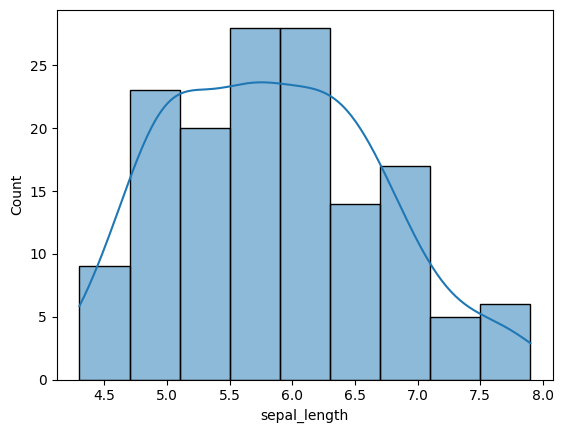

<Axes: >

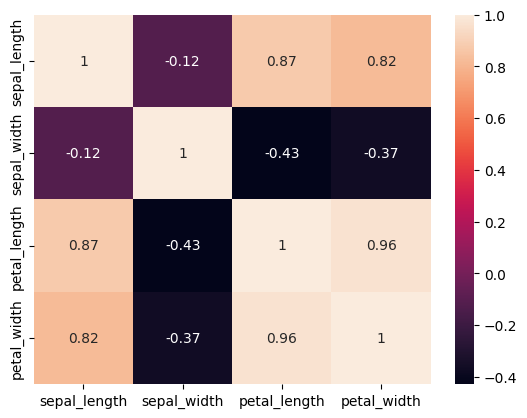

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df=sns.load_dataset('iris')

df.head()

sns.histplot(df['sepal_length'] , kde=True)
plt.show()

# sns.pairplot(df)
# plt.show()
df=df.select_dtypes(include='number')
sns.heatmap(data=df.corr(), annot=True)


In [4]:
!pip install -q faiss-cpu spacy
!python -m spacy download en_core_web_md

import faiss
import numpy as np
import spacy

nlp = spacy.load('en_core_web_md')

words = ['king', 'queen', 'man', 'woman', 'apple', 'orange']
vectors = np.array([nlp(w).vector for w in words]).astype('float32')

index = faiss.IndexFlatL2(vectors.shape[1])
index.add(vectors)

query_word = 'royal'
query_vec = np.array([nlp(query_word).vector], dtype='float32')

distances, indices = index.search(query_vec, k=3)

print(f"\nQuery: {query_word}")
for i in range(3):
    print(f"{i+1}. {words[indices[0][i]]} (distance: {distances[0][i]:.4f})")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 39.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 13.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.

Query: royal
1. queen (distance: 62.3108)
2. king (distance: 71.0804)
3. man (distance: 75.4891)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


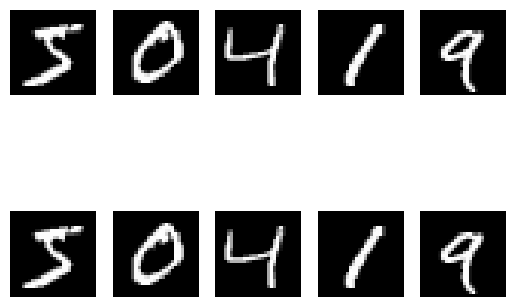

In [5]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

(x_train, _), _ = mnist.load_data()
x_train = x_train.astype("float32") / 255.0

# Add and remove simple Gaussian noise
noise = tf.random.normal(x_train[:5].shape, stddev=0.5)
noisy = x_train[:5] + noise
denoised = tf.clip_by_value(noisy - noise, 0, 1)

# Show results
for i in range(5):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis('off')
    plt.subplot(2, 5, i+6)
    plt.imshow(denoised[i], cmap='gray')
    plt.axis('off')
plt.show()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/618 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/4 [00:00<?, ?it/s]

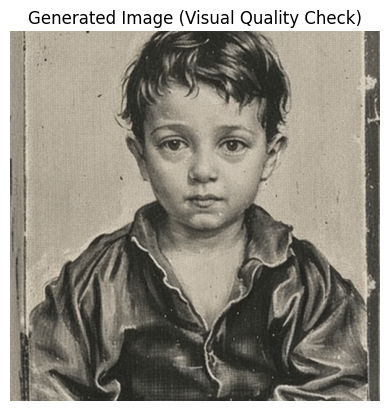

In [6]:
!pip install -q diffusers transformers accelerate torch torchvision

from diffusers import AutoPipelineForText2Image
import torch
import matplotlib.pyplot as plt

pipe = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/sd-turbo",
    torch_dtype=torch.float32
)


prompt = "A small boy"
image = pipe(prompt, num_inference_steps=4, guidance_scale=0.0).images[0]


plt.imshow(image)
plt.axis("off")
plt.title("Generated Image (Visual Quality Check)")
plt.show()

In [7]:
!pip install -q transformers datasets

from transformers import AutoTokenizer, AutoModelForCausalLM, Trainer, TrainingArguments
from datasets import Dataset
import math, os

os.environ["WANDB_DISABLED"] = "true"

texts = [
    "AI is changing the world.",
    "Machine Learning learns from data.",
    "Generative AI creates art and text.",
    "NLP helps computers understand language."
]

data = Dataset.from_dict({"text": texts}).train_test_split(test_size=0.25)

tokenizer = AutoTokenizer.from_pretrained("distilgpt2")
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained("distilgpt2")

def tok(e):
    t = tokenizer(e["text"], truncation=True, padding="max_length", max_length=64)
    t["labels"] = t["input_ids"].copy()
    return t

tok_data = data.map(tok, batched=True)
tok_data.set_format("torch")

args = TrainingArguments(output_dir="out", num_train_epochs=1, per_device_train_batch_size=1, report_to="none")
trainer = Trainer(model=model, args=args, train_dataset=tok_data["train"], eval_dataset=tok_data["test"])
trainer.train()

text = "AI will"
out = model.generate(**tokenizer(text, return_tensors="pt"), max_new_tokens=30)
print("\nGenerated:", tokenizer.decode(out[0], skip_special_tokens=True))

res = trainer.evaluate()
print("Perplexity:", round(math.exp(res["eval_loss"]), 2))


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Step,Training Loss


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



Generated: AI will be the first time that the government will be able to make a decision on the future of the country’s economy.







/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Perplexity: 55.46


In [8]:
from transformers import pipeline
from nltk.translate.bleu_score import sentence_bleu
# tiny example
summarizer = pipeline("summarization", model="sshleifer/distilbart-cnn-12-6")
article = "AI helps automate tasks. It speeds up research and product development."
ref_summary = "AI automates tasks and speeds research."
out = summarizer(article, max_length=20)[0]["summary_text"]
print("Gen:", out)
# BLEU as quick proxy (not ideal for summarization but simple)
bleu = sentence_bleu([ref_summary.split()], out.split())
print("BLEU (approx):", round(bleu,3))

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Device set to use cpu
Your min_length=56 must be inferior than your max_length=20.
Your max_length is set to 20, but your input_length is only 15. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=7)
/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1633: UserWarning: Unfeasible length constraints: `min_length` (56) is larger than the maximum possible length (20). Generation will stop at the defined maximum length. You should decrease the minimum length and/or increase the maximum length.
  warnings.warn(


Gen:  AI helps automate tasks and speeds up research and product development . AI helps speed up research
BLEU (approx): 0.0


/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from transformers import pipeline

# small document store
docs = [
 "TensorFlow is an ML framework.",
 "PyTorch is popular for research.",
 "FAISS provides vector search.",
 "RAG combines retrieval and generation."
]
vect = TfidfVectorizer().fit_transform(docs)
nn = NearestNeighbors(n_neighbors=2).fit(vect)
query = "how to combine retrieval with generation?"
qv = TfidfVectorizer().fit(docs).transform([query])
_, idx = nn.kneighbors(qv)
ctx = " ".join([docs[i] for i in idx[0]])
generator = pipeline("text-generation", model="gpt2")
prompt = f"Context: {ctx}\nAnswer the query: {query}\n"
print(generator(prompt, max_length=120)[0]["generated_text"])

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cpu
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=120) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Context: RAG combines retrieval and generation. FAISS provides vector search.
Answer the query: how to combine retrieval with generation?
Answer the query: how to combine retrieval with generation?
Answer the query: how to combine retrieval with generation?
Answer the query: how to combine retrieval with generation?
Answer the query: how to combine retrieval with generation?
Answer the query: how to combine retrieval with generation?
Answer the query: how to combine retrieval with generation?
Answer the query: how to combine retrieval with generation?
Answer the query: how to combine retrieval with generation?
Answer the query: how to combine retrieval with generation?
Answer the query: how to combine retrieval with generation?
Answer the query: how to combine retrieval with generation?
Answer the query: how to combine retrieval with generation?
Answer the query: how to combine retrieval with generation?
Answer the query: how to combine retrieval with generation?
Answer the query: how 

In [10]:
from transformers import pipeline

# load small pretrained text generator
gen = pipeline("text-generation", model="distilgpt2")

# prompts that may show bias
prompts = ["The nurse said", "The engineer said", "The teacher said"]

print("=== Raw Outputs ===")
for p in prompts:
    print(p, "->", gen(p, max_length=15, do_sample=True)[0]["generated_text"])

# simple bias mitigation: filter gendered words
def mitigate(text):
    banned = ["he", "she", "him", "her"]
    words = text.split()
    return " ".join([w for w in words if w.lower() not in banned])

print("\n=== Filtered Outputs ===")
for p in prompts:
    out = gen(p, max_length=15, do_sample=True)[0]["generated_text"]
    print(p, "->", mitigate(out))


Device set to use cpu
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=15) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== Raw Outputs ===


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=15) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The nurse said -> The nurse said she was surprised by the decision.



"I didn't believe she was a victim. She was a victim," Ms. Hough said.
Ms. Hough said the university was considering the matter.
"The university is considering the matter," she said.


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=15) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

The teacher said -> The teacher said the teacher asked her about her experience in the school.






















































































































































































































































=== Filtered Outputs ===


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=15) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The nurse said -> The nurse said heard the ambulance rushing to the scene.


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=15) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The engineer said -> The engineer said: ‪ ‫ The most important thing to do, if you’re doing this, is to get on with the project.” The company says that was not familiar with the project and that the project was completely funded. ‪ The company says the project was not a project that needed funding. ‪ The company said it was confident that the project would not be involved in the project, but did not believe that it was worth the money. ‪ The company said that it had a "very low" budget and that its project would be funded by the government. ‪ The company has not commented on the project but said that it would have to make sure that it is used properly. ‪ The company said that it would be running a test of a product, and that it would be the first to do it. The company said that they had not received their funding from the government. ‪
The teacher said -> The teacher said that was told that the teacher was going to take a bath with and that would not be allowed to do anything like that

In [14]:
from transformers import pipeline

gen = pipeline("text-generation", model="distilgpt2")

prompts = ["The nurse said", "The engineer said", "The teacher said"]

print("=== Raw Outputs ===")
for p in prompts:
    print(p, "->", gen(p, max_length=15, do_sample=True)[0]["generated_text"])

def mitigate(text):
    banned = ["he", "she", "him", "her"]
    words = text.split()
    return " ".join([w for w in words if w.lower() not in banned])

print("\n=== Filtered Outputs ===")
for p in prompts:
    out = gen(p, max_length=15, do_sample=True)[0]["generated_text"]
    print(p, "->", mitigate(out))


Device set to use cpu
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=15) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== Raw Outputs ===


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=15) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The nurse said -> The nurse said she had just been diagnosed with a genetic disorder. "It's a very scary thing," she said.


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=15) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

The teacher said -> The teacher said the school had been in touch with the parents and had been informed of the situation.




The school has not been informed of the complaint and has been advised to contact the district superintendent.

=== Filtered Outputs ===


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=15) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The nurse said -> The nurse said doesn't have the stomach for the trip and that didn't know it was happening until came to the hospital where was treated and the nurse came to and said, 'I'm sick of it. The nurse said I'm sick of it, I'm sick of it. I'm sick of it.'"


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=15) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


The engineer said -> The engineer said that the new cars would be more stable than the old ones, but had already gone for the first time in the history of the car, the new Mercedes had been the only car that could be used for those needs. “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement - “ Advertisement
The tea

In [11]:
import random

class Agent:
    def __init__(self, name): self.name = name
    def act(self, context):
        if "food" in context: return f"{self.name}: Let's cook!"
        if "danger" in context: return f"{self.name}: Let's hide!"
        return f"{self.name}: Let's explore!"

agents = [Agent("Alpha"), Agent("Beta")]

# simple environment simulation
states = ["food nearby", "danger ahead", "nothing around"]
for step in range(3):
    context = random.choice(states)
    print(f"\nEnvironment: {context}")
    for a in agents:
        print(a.act(context))



Environment: nothing around
Alpha: Let's explore!
Beta: Let's explore!

Environment: food nearby
Alpha: Let's cook!
Beta: Let's cook!

Environment: food nearby
Alpha: Let's cook!
Beta: Let's cook!


In [12]:
 ! git clone https://github.com/suyash1574/genai

Cloning into 'genai'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 6 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), 335.76 KiB | 11.19 MiB/s, done.
